In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Data

In [3]:
# use this to retrive the titanic data online
titanic = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv') 
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(titanic.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


## Filter Unnecessary Fields

In [5]:
titanic = titanic[['Pclass','Sex', 'Age', 'SibSp', 'Fare', 'Survived' ]]
titanic.head(10)

,Pclass,Sex,Age,SibSp,Fare,Survived
0,3,male,22.0,1,7.2500,0
1,1,female,38.0,1,71.2833,1
2,3,female,26.0,0,7.9250,1
3,1,female,35.0,1,53.1000,1
4,3,male,35.0,0,8.0500,0
5,3,male,NaN,0,8.4583,0
6,1,male,54.0,0,51.8625,0
7,3,male,2.0,3,21.0750,0
8,3,female,27.0,0,11.1333,1
9,2,female,14.0,1,30.0708,1


## Deal with missing values

In [6]:
missing_data = titanic.isnull().any()
print(missing_data)

Pclass      False
Sex         False
Age          True
SibSp       False
Fare        False
Survived    False
dtype: bool


The above means that we only need to deal with missing age in this version of the titanic dataset

### Deal with missing ages

In [7]:
missing_ages = titanic[titanic['Age'].isnull()].shape[0]
print('Before Filtering Out Missing Ages, No of Records is ', missing_ages)

meanAge = int(titanic['Age'].mean())
titanic = titanic.fillna(meanAge)

missing_ages = titanic[titanic['Age'].isnull()].shape[0]
print('Before Filtering Out Missing Ages, No of Records is ', missing_ages)

Before Filtering Out Missing Ages, No of Records is  177
Before Filtering Out Missing Ages, No of Records is  0


### Thorough checking/dealing for missing-ness just in case

In [8]:
for col in titanic.columns:
    
    missing_data = titanic[titanic[col].isnull()].shape[0]
    print('Before Filtering Out Missing {}, No of Records is {} '.format(col, missing_data))
    
    titanic = titanic.dropna()
    titanic.head(10)
    
    missing_data = titanic[titanic[col].isnull()].shape[0]
    print('Before Filtering Out Missing {}, No of Records is {} '.format(col, missing_data))
    


Before Filtering Out Missing Pclass, No of Records is 0 
Before Filtering Out Missing Pclass, No of Records is 0 
Before Filtering Out Missing Sex, No of Records is 0 
Before Filtering Out Missing Sex, No of Records is 0 
Before Filtering Out Missing Age, No of Records is 0 
Before Filtering Out Missing Age, No of Records is 0 
Before Filtering Out Missing SibSp, No of Records is 0 
Before Filtering Out Missing SibSp, No of Records is 0 
Before Filtering Out Missing Fare, No of Records is 0 
Before Filtering Out Missing Fare, No of Records is 0 
Before Filtering Out Missing Survived, No of Records is 0 
Before Filtering Out Missing Survived, No of Records is 0 


## Stats and Visualisaiton for classes

### Survival rates

<BarContainer object of 2 artists>

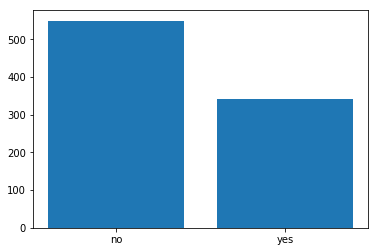

In [9]:
not_survived = titanic[titanic['Survived']==0].shape[0]
survived = titanic[titanic['Survived']==1].shape[0]
plt.bar(['no','yes'], [not_survived, survived])

The above shows that the more dominant class is not survived. In other words, not surviving is more likely than surviving for people in the titanic

### Gender/Survival stats.
Let us get some stats. regarding gender

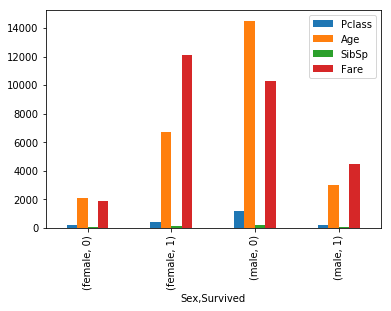

In [10]:
titanic.groupby(['Sex','Survived']).sum().plot.bar()

The above operation grouped by gender and the summed over all attributes. We might want to consider the mean here as it is more meaningful :-)

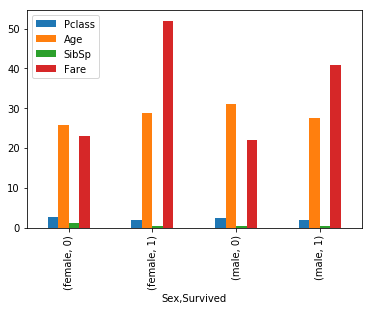

In [11]:
titanic.groupby(['Sex','Survived']).mean().plot.bar()

### Gender/Survival rates

In [12]:
titanic_sex_survive = titanic.groupby(['Survived', 'Sex'])['Survived'].count()
titanic_sex_survive.head()

Survived  Sex   
0         female     81
          male      468
1         female    233
          male      109
Name: Survived, dtype: int64

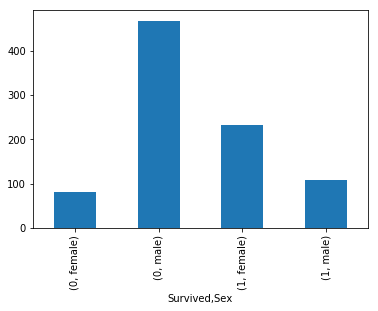

In [13]:
titanic_sex_survive.plot.bar()

# Classifying the titanic dataset

Ok so now we are ready to do more serious classification after we gained some insight into our dataset

In [14]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

from sklearn.model_selection import train_test_split


In [15]:
X = titanic[['Pclass','Sex', 'Age', 'SibSp', 'Fare']]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [16]:
y_test.shape[0]

295

In [17]:
# the below will cause an error sicne there are categorical data taht needs to be converted to numerical
# DT = DecisionTreeClassifier().fit(X_train, y_train)

## Categorical to Numerical

In [18]:
labels = titanic['Sex'].astype('category').cat.categories.tolist()
replace_sex = {'Sex' : {k: v for k,v in zip(labels,list(range(len(labels)+1)))}}
print(replace_sex)


titanic.replace(replace_sex, inplace=True)

titanic.head()

{'Sex': {'female': 0, 'male': 1}}


,Pclass,Sex,Age,SibSp,Fare,Survived
0,3,1,22.0,1,7.2500,0
1,1,0,38.0,1,71.2833,1
2,3,0,26.0,0,7.9250,1
3,1,0,35.0,1,53.1000,1
4,3,1,35.0,0,8.0500,0


## Split the Data

In [19]:
X = titanic[['Sex', 'Age', 'SibSp', 'Fare', 'Pclass']]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Fit the classifiers

In [20]:
DT   = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)
kNN  = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
LogR = LogisticRegression(max_iter=100).fit(X_train, y_train)

### Visualise the tree 

In [21]:
# plt.figure(figsize=(14, 12))
# plot_tree(DT, filled=True)
# plt.show()

### Confusion Matrix and Perfromance Metrics

Let us plot the normalise confusion matrix using true classes to get the pr(detect+) and pr(detect-) directly inside the matrix. you can caclulate these as well using the recall score.

Let us do it first for the decision tree and then we write a helper function to return the metrics and confusion matrix for other classifiers

### pr(detect)

pr(detect+) for DT =  0.8971428571428571
pr(detect-) for DT=  0.7083333333333334


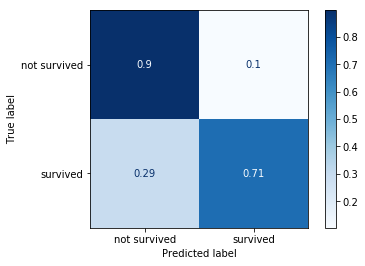

In [29]:
target_labels = ['not survived', 'survived']
confusion   = plot_confusion_matrix(DT, X_test, y_test, display_labels=target_labels, cmap=plt.cm.Blues, normalize='true')
#print('normalised confusion matrix as per actual classes =\n ', confusion.confusion_matrix)
pr_detect_plus  = confusion.confusion_matrix[0,0]
pr_detect_minus = confusion.confusion_matrix[1,1]
print('pr(detect+) for DT = ', pr_detect_plus)
print('pr(detect-) for DT= ', pr_detect_minus)

### pr(predict)
Now normalise using prediction to get the pr(predict+) and pr(predict-)

pr(predict+) =  0.8177083333333334
pr(predict-) =  0.8252427184466019


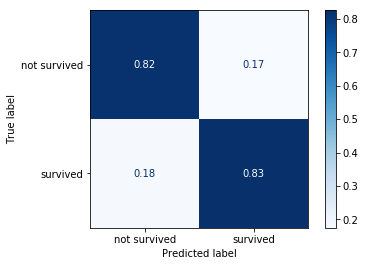

In [30]:
confusion = plot_confusion_matrix(DT, X_test, y_test, display_labels=target_labels, cmap=plt.cm.Blues, normalize='pred')
#print('normalised confusion matrix as per predicted classes =\n ',confusion.confusion_matrix)
pr_predict_plus  = confusion.confusion_matrix[0,0]
pr_predict_minus = confusion.confusion_matrix[1,1]
print('pr(predict+) = ', pr_predict_plus)
print('pr(predict-) = ', pr_predict_minus)

### Helper Function
Now we write our helper function

In [32]:
def plot_confusion_predict(cls, X_test, y_test, display_labels):
    confusion = plot_confusion_matrix(cls, X_test, y_test, display_labels=display_labels, cmap=plt.cm.Blues,
                                      normalize='pred')
    
    pr_predict_plus  = confusion.confusion_matrix[0,0]
    pr_predict_minus = confusion.confusion_matrix[1,1]
        
    print('pr(predict+) = ', pr_predict_plus)
    print('pr(predict-) = ', pr_predict_minus)
    print('')
        
    return pr_predict_plus, pr_predict_minus, confusion


def plot_confusion_detect(cls, X_test, y_test, display_labels):
    confusion = plot_confusion_matrix(cls, X_test, y_test, display_labels=display_labels, cmap=plt.cm.Blues,
                                      normalize='true')
    
    pr_detect_plus  = confusion.confusion_matrix[0,0]
    pr_detect_minus = confusion.confusion_matrix[1,1]
        
    print('pr(detect+) = ', pr_detect_plus)
    print('pr(detect-) = ', pr_detect_minus)
    print('')
    
    return pr_detect_plus, pr_detect_minus, confusion


def plot_confusion_pred(cls, X_test, y_test, display_labels, detect_predict ='true'):
    if detect_predict =='true': return plot_print_confusion_detect(cls, X_test, y_test, display_labels)
    if detect_predict =='pred': return plot_print_confusion_predict(cls, X_test, y_test, display_labels)
    

pr(detect+) =  0.8971428571428571
pr(detect-) =  0.7083333333333334

pr(detect+) =  0.8457142857142858
pr(detect-) =  0.5416666666666666

pr(detect+) =  0.8742857142857143
pr(detect-) =  0.7166666666666667

The max detect is 0.8971428571428571 and the winner classifier is Decision Tree


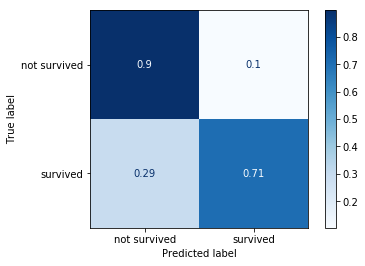

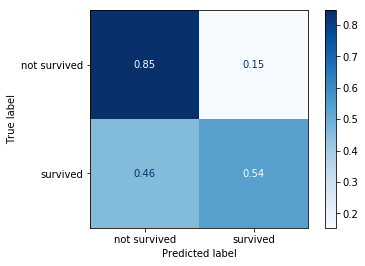

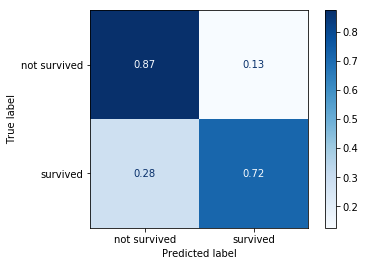

In [36]:
pr_detect_plus_DT, _ ,_ = plot_confusion_detect(DT, X_test, y_test, display_labels=target_labels)
pr_detect_plus_kNN, _ ,_ = plot_confusion_detect(kNN, X_test, y_test, display_labels=target_labels)
pr_detect_plus_LogR, _ ,_ = plot_confusion_detect(LogR, X_test, y_test, display_labels=target_labels)

pr_detect_plus          = [pr_detect_plus_DT, pr_detect_plus_kNN, pr_detect_plus_LogR ]
pr_detect_plus_max      = max(pr_detect_plus)
pr_detect_plus_max_ind  = pr_detect_plus.index(detect_plus_val)

classifiers_names = ["Decision Tree", "Nearest Neighbors",  "Logistic Regression"]

print('The max detect is {} and the winner classifier is {}'.format(detect_plus_val, 
                                                                classifiers_names[pr_detect_plus_max_ind]))

## Your turn

Optimise the max_depth, k and apply cross validation and see if this improve the detection rates